# Portugal Oral Health Voucher Program: exploratory analysis and forecasting

This notebook was prepared as part of a Data Science fellowship portfolio at Nova SBE Data Science Knowledge Centre (now DOT Centre). It explores public monthly data on Portugal's oral health voucher program (`cheques-dentista`), a National Health Service initiative that issues dental-care vouchers to eligible groups such as children and young people, pregnant SNS users, older adults with social support, people living with HIV/AIDS, and users covered by oral-cancer early-intervention pathways.
Program reference: [SNS24 - pedir cheques-dentista](https://www.sns24.gov.pt/guia/pedir-cheques-dentista/)

## Goals

1. Validate and clean the dataset so the analysis runs reproducibly.
2. Describe how issued vouchers, used vouchers, and completed treatments vary by month, target population, provider entity, and intervention area.
3. Identify seasonality and time-series structure in voucher usage.
4. Build a simple, leakage-aware forecasting model for monthly vouchers used and compare it with a seasonal baseline.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from statsmodels.graphics import tsaplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("data") / "saude-oral.csv"
START_DATE = "2017-01-01"
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 5), "axes.titleweight": "bold"})

fmt_thousands = FuncFormatter(lambda x, pos: f"{x/1_000:,.0f}k")
VALUE_COLUMNS = ["Nº Cheques Emitidos", "Nº Cheques Utilizados", "Nº Tratamentos Efetuados"]


## 1. Load and validate the data

The raw CSV uses semicolons as separators and stores the month in `YYYY-MM` format. I drop the row-level `ID` field because it is a compound label derived from the other columns and does not add analytical information.

The notebook focuses on January 2017 onward, matching the original project scope and keeping the analysis on the most recent, comparable period. The available data ends in July 2022, so the forecasting holdout is January-July 2022 rather than a full calendar year.


In [2]:
raw = pd.read_csv(DATA_PATH, sep=";")

saude_oral = raw.drop(columns="ID").copy()
saude_oral["Período"] = pd.to_datetime(saude_oral["Período"], format="%Y-%m")
saude_oral = saude_oral.sort_values("Período").reset_index(drop=True)

data = saude_oral.loc[saude_oral["Período"] >= START_DATE].copy()

print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns")
print(f"Analysis period: {data['Período'].min():%Y-%m} to {data['Período'].max():%Y-%m}")
print(f"Number of monthly observations: {data['Período'].nunique()}")
display(data.head())


Raw shape: 1,197 rows x 8 columns
Analysis period: 2017-01 to 2022-07
Number of monthly observations: 67


,Período,Entidade,População-Alvo,Âmbito de Intervenção,Nº Cheques Emitidos,Nº Cheques Utilizados,Nº Tratamentos Efetuados
728,2017-01-01,Centros de Saúde (consultas de Medicina Dentária),Utentes do SNS,Prevenção e tratamento em saúde oral,809,266,1605
729,2017-01-01,Centros de Saúde (consultas de Higiene Oral),"Crianças e jovens (7, 10 e 13 anos)",Prevenção em saúde oral,4886,2120,10581
730,2017-01-01,Consultórios Privados,Portadores VIH/Sida,Tratamento em saúde oral,137,138,275
731,2017-01-01,Consultórios Privados,Idosos com complemento solidário,Tratamento em saúde oral,829,658,1255
732,2017-01-01,Consultórios Privados,Crianças e jovens (até 18 anos),Prevenção e tratamento em saúde oral,48300,12613,47096


In [3]:
quality_summary = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_values": data.isna().sum(),
    "unique_values": data.nunique(),
})

display(quality_summary)

expected_months = pd.period_range(data["Período"].min(), data["Período"].max(), freq="M")
observed_months = data["Período"].dt.to_period("M").sort_values().unique()
missing_months = sorted(set(expected_months) - set(observed_months))

print(f"Missing months in analysis period: {len(missing_months)}")
if missing_months:
    print(missing_months)


,dtype,missing_values,unique_values
Período,datetime64[ns],0,67
Entidade,object,0,3
População-Alvo,object,0,7
Âmbito de Intervenção,object,0,4
Nº Cheques Emitidos,int64,0,461
Nº Cheques Utilizados,int64,0,464
Nº Tratamentos Efetuados,int64,0,401


Missing months in analysis period: 0


## 2. Descriptive view

The first tables summarize the program by provider entity, target population, and intervention area. All aggregations are restricted to numeric columns to avoid pandas version errors when summing datetime fields.


In [4]:
def add_total_row(table: pd.DataFrame) -> pd.DataFrame:
    """Append a numeric total row to a grouped summary table."""
    table = table.copy()
    table.loc["Total"] = table.sum(numeric_only=True)
    return table

by_entity = add_total_row(
    data.groupby("Entidade", observed=True)[VALUE_COLUMNS]
    .sum()
    .sort_values("Nº Cheques Utilizados", ascending=False)
)

by_population = add_total_row(
    data.groupby("População-Alvo", observed=True)[VALUE_COLUMNS]
    .sum()
    .sort_values("Nº Cheques Utilizados", ascending=False)
)

by_intervention = add_total_row(
    data.groupby("Âmbito de Intervenção", observed=True)[VALUE_COLUMNS]
    .sum()
    .sort_values("Nº Cheques Utilizados", ascending=False)
)

print("By provider entity")
display(by_entity.style.format("{:,.0f}"))

print("By target population")
display(by_population.style.format("{:,.0f}"))

print("By intervention area")
display(by_intervention.style.format("{:,.0f}"))


By provider entity


,Nº Cheques Emitidos,Nº Cheques Utilizados,Nº Tratamentos Efetuados
Entidade,,,
Consultórios Privados,"20,523,551","12,655,775","41,669,752"
Centros de Saúde (consultas de Higiene Oral),"1,023,090","548,630","3,781,487"
Centros de Saúde (consultas de Medicina Dentária),"1,907,384","517,538","2,611,950"
Total,"23,454,025","13,721,943","48,063,189"


By target population


,Nº Cheques Emitidos,Nº Cheques Utilizados,Nº Tratamentos Efetuados
População-Alvo,,,
Crianças e jovens (até 18 anos),"16,381,462","9,527,713","36,088,499"
Grávidas seguidas no SNS,"3,634,421","2,736,058","5,043,921"
"Crianças e jovens (7, 10 e 13 anos)","1,023,090","548,630","3,781,487"
Utentes do SNS,"1,907,384","517,538","2,611,950"
Idosos com complemento solidário,"298,905","251,502","461,345"
Intervenção precoce no cancro oral,"162,850","102,635",0
Portadores VIH/Sida,"45,913","37,867","75,987"
Total,"23,454,025","13,721,943","48,063,189"


By intervention area


,Nº Cheques Emitidos,Nº Cheques Utilizados,Nº Tratamentos Efetuados
Âmbito de Intervenção,,,
Prevenção e tratamento em saúde oral,"21,923,267","12,781,309","43,744,370"
Prevenção em saúde oral,"1,023,090","548,630","3,781,487"
Tratamento em saúde oral,"344,818","289,369","537,332"
Intervenção precoce no cancro Oral,"162,850","102,635",0
Total,"23,454,025","13,721,943","48,063,189"


In [5]:
entity_population = (
    data.pivot_table(
        index="População-Alvo",
        columns="Entidade",
        values="Nº Cheques Utilizados",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index()
)

display(entity_population.style.format("{:,.0f}"))


Entidade,Centros de Saúde (consultas de Higiene Oral),Centros de Saúde (consultas de Medicina Dentária),Consultórios Privados
População-Alvo,,,
"Crianças e jovens (7, 10 e 13 anos)","548,630",0,0
Crianças e jovens (até 18 anos),0,0,"9,527,713"
Grávidas seguidas no SNS,0,0,"2,736,058"
Idosos com complemento solidário,0,0,"251,502"
Intervenção precoce no cancro oral,0,0,"102,635"
Portadores VIH/Sida,0,0,"37,867"
Utentes do SNS,0,"517,538",0


Most voucher use is concentrated in private dental offices (`Consultórios Privados`) and in the children-and-young-people target group. Public health-center categories are more specific: hygiene appointments are associated with children aged 7, 10 and 13, while dental-medicine appointments cover SNS users.

The oral-cancer early-intervention category has issued and used vouchers but zero completed treatments in this dataset. That is consistent with its role as a diagnostic pathway rather than a conventional dental-treatment intervention.


## 3. Monthly dynamics

The program is strongly seasonal. Issued vouchers, used vouchers, and completed treatments move together, although issued vouchers lead usage because vouchers can be used after issuance.


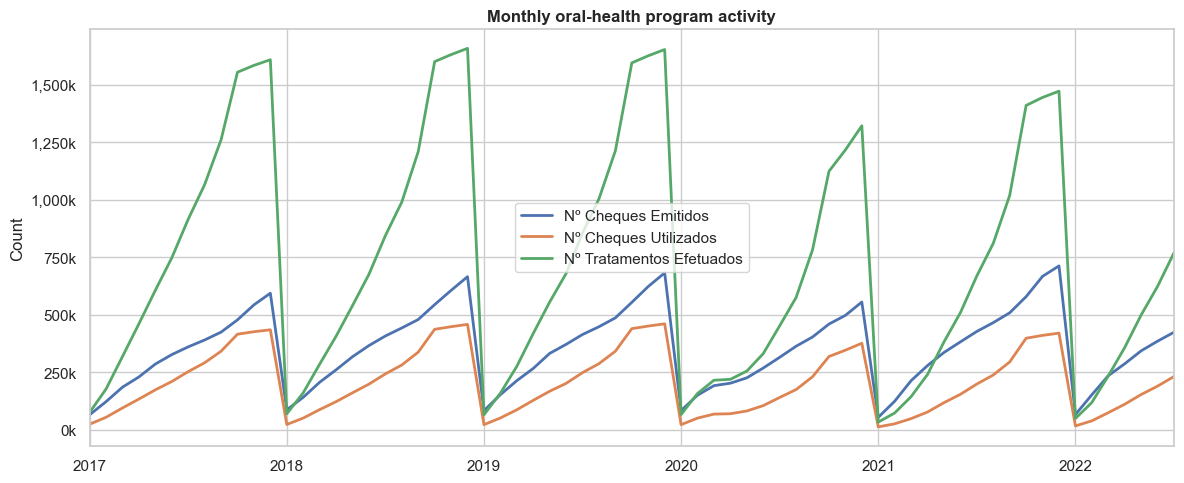

,Nº Cheques Emitidos,Nº Cheques Utilizados,Nº Tratamentos Efetuados
Nº Cheques Emitidos,1.000,0.959,0.948
Nº Cheques Utilizados,0.959,1.000,0.999
Nº Tratamentos Efetuados,0.948,0.999,1.000


In [6]:
monthly = (
    data.groupby("Período", observed=True)[VALUE_COLUMNS]
    .sum()
    .asfreq("MS")
)

ax = monthly.plot(linewidth=2)
ax.set_title("Monthly oral-health program activity")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(fmt_thousands)
plt.tight_layout()
plt.show()

display(monthly.corr().style.format("{:.3f}"))


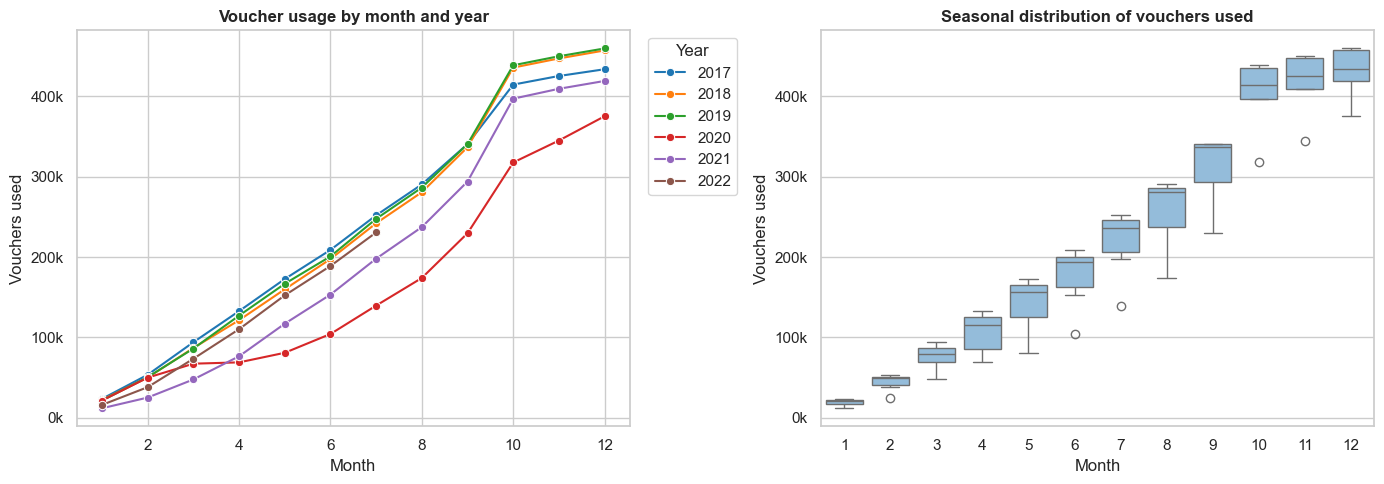

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=monthly.assign(year=monthly.index.year, month=monthly.index.month),
    x="month",
    y="Nº Cheques Utilizados",
    hue="year",
    marker="o",
    palette="tab10",
    ax=axes[0],
)
axes[0].set_title("Voucher usage by month and year")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Vouchers used")
axes[0].yaxis.set_major_formatter(fmt_thousands)
axes[0].legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(
    data=monthly.assign(month=monthly.index.month),
    x="month",
    y="Nº Cheques Utilizados",
    color="#88BDE6",
    ax=axes[1],
)
axes[1].set_title("Seasonal distribution of vouchers used")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Vouchers used")
axes[1].yaxis.set_major_formatter(fmt_thousands)

plt.tight_layout()
plt.show()


## 4. Time-series diagnostics

I use an additive seasonal decomposition with a 12-month period. Multiplicative decomposition is less robust for public-program data because zero or near-zero values can appear in subgroups; additive decomposition is easier to interpret on count data.


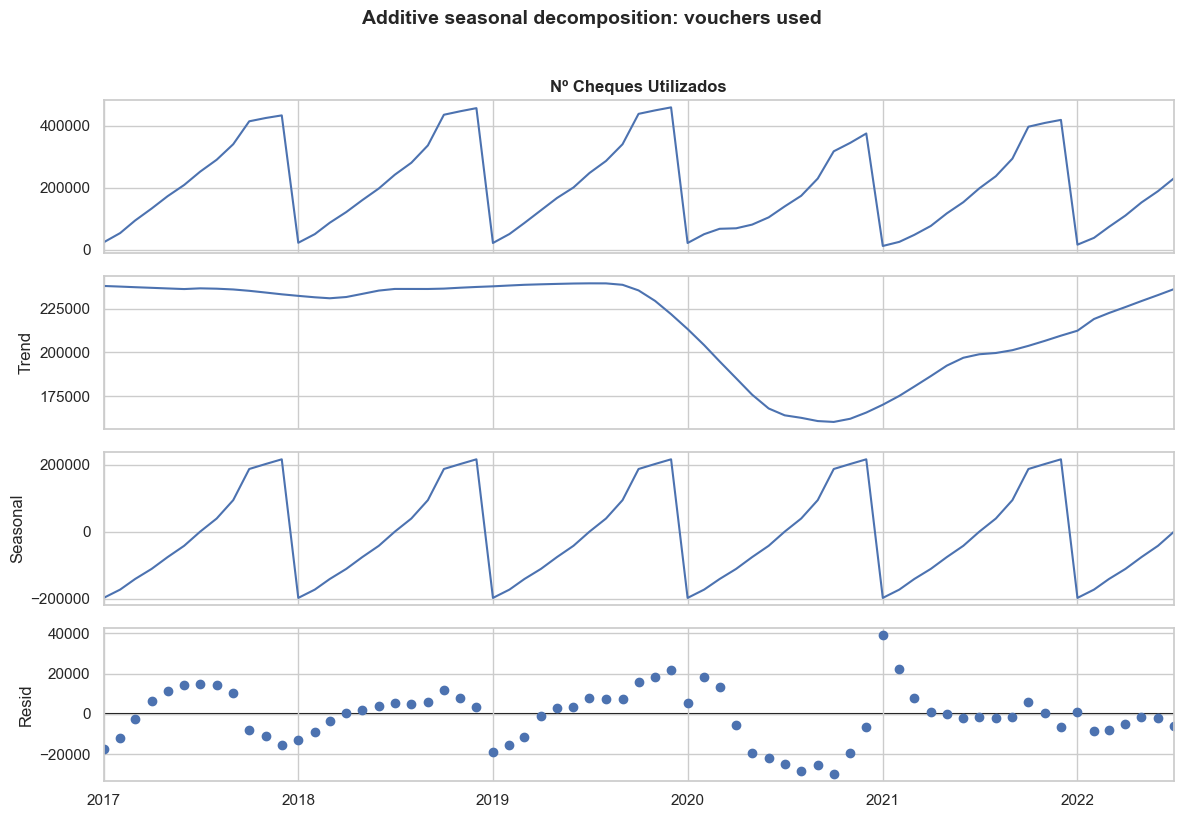

In [8]:
used_series = monthly["Nº Cheques Utilizados"]

decomposition = seasonal_decompose(used_series, model="additive", period=12, extrapolate_trend="freq")
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Additive seasonal decomposition: vouchers used", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


ADF statistic: -3.478
p-value: 0.042
Critical value (1%): -4.137
Critical value (5%): -3.495
Critical value (10%): -3.176


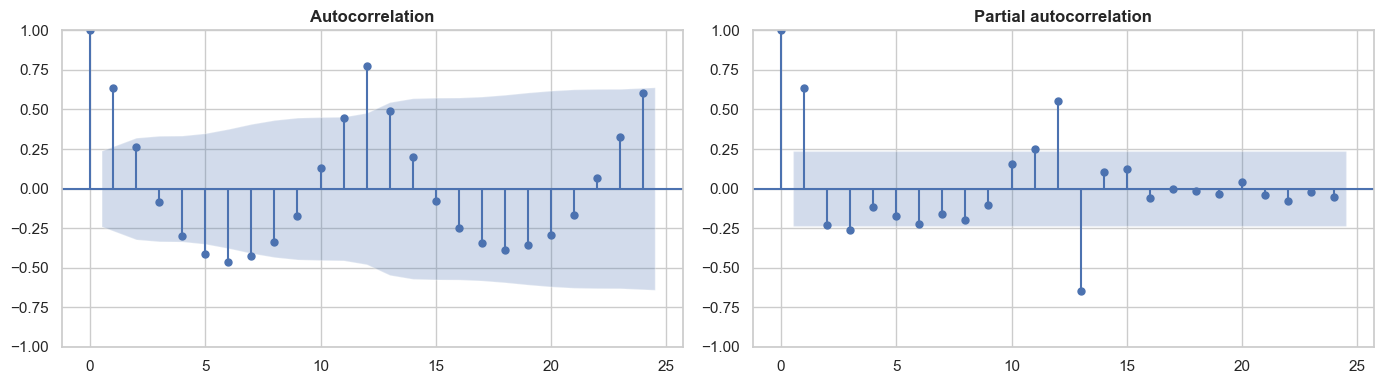

In [9]:
adf_result = adfuller(used_series, autolag="AIC", regression="ct", maxlag=12)

print(f"ADF statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.3f}")
for key, value in adf_result[4].items():
    print(f"Critical value ({key}): {value:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tsaplots.plot_acf(used_series, lags=24, ax=axes[0])
tsaplots.plot_pacf(used_series, lags=24, ax=axes[1], method="ywm")
axes[0].set_title("Autocorrelation")
axes[1].set_title("Partial autocorrelation")
plt.tight_layout()
plt.show()


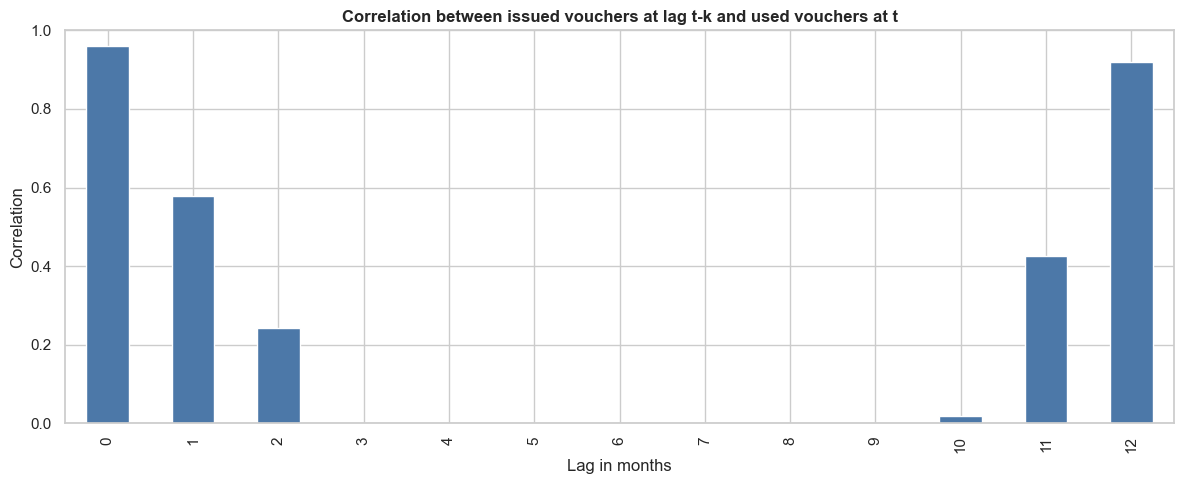

,0,1,2,3,4,5,6,7,8,9,10,11,12
correlation,0.959,0.579,0.242,-0.020,-0.210,-0.348,-0.441,-0.461,-0.441,-0.311,0.017,0.427,0.921


In [10]:
def lagged_correlation(left: pd.Series, right: pd.Series, max_lag: int = 12) -> pd.Series:
    """Correlation between left(t-lag) and right(t)."""
    correlations = {}
    for lag in range(max_lag + 1):
        correlations[lag] = left.shift(lag).corr(right)
    return pd.Series(correlations, name="correlation")

issued_used_corr = lagged_correlation(
    monthly["Nº Cheques Emitidos"],
    monthly["Nº Cheques Utilizados"],
    max_lag=12,
)

ax = issued_used_corr.plot(kind="bar", color="#4C78A8")
ax.set_title("Correlation between issued vouchers at lag t-k and used vouchers at t")
ax.set_xlabel("Lag in months")
ax.set_ylabel("Correlation")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

display(issued_used_corr.to_frame().T.style.format("{:.3f}"))


The diagnostics confirm the visual pattern: voucher usage has strong trend and seasonality, and issued vouchers are highly correlated with later usage over the first few lags. This supports adding lagged values and month indicators to the forecasting model.


## 5. Predictive model

The original model used same-month `Nº Cheques Utilizados` split by entity to predict total same-month `Nº Cheques Utilizados`. That leaks the target: those subgroup values add up to the quantity being predicted.

The revised model predicts monthly vouchers used with information that is defensible at prediction time:

- current-month vouchers issued, split by entity;
- lagged total vouchers issued and used (`t-1`, `t-2`, `t-3`, `t-12`);
- three-month rolling means based only on prior months;
- calendar features for month, quarter, trend, and the COVID disruption period.

The holdout period is January-July 2022, the last seven months available in the file.


In [11]:
issued_by_entity = (
    data.pivot_table(
        index="Período",
        columns="Entidade",
        values="Nº Cheques Emitidos",
        aggfunc="sum",
        fill_value=0,
    )
    .asfreq("MS")
)
issued_by_entity.columns = [f"issued_{column}" for column in issued_by_entity.columns]

model_df = monthly.join(issued_by_entity)
model_df["month"] = model_df.index.month
model_df["quarter"] = model_df.index.quarter
model_df["time_index"] = np.arange(len(model_df))
model_df["covid_period"] = ((model_df.index >= "2020-03-01") & (model_df.index <= "2021-03-01")).astype(int)

for lag in [1, 2, 3, 12]:
    model_df[f"used_lag_{lag}"] = model_df["Nº Cheques Utilizados"].shift(lag)
    model_df[f"issued_lag_{lag}"] = model_df["Nº Cheques Emitidos"].shift(lag)

model_df["used_rolling_3"] = model_df["Nº Cheques Utilizados"].shift(1).rolling(3).mean()
model_df["issued_rolling_3"] = model_df["Nº Cheques Emitidos"].shift(1).rolling(3).mean()
model_df = model_df.dropna()

feature_columns = [column for column in model_df.columns if column not in VALUE_COLUMNS]
target_column = "Nº Cheques Utilizados"

train = model_df.loc[:"2021-12-01"]
test = model_df.loc["2022-01-01":]

X_train = train[feature_columns]
y_train = train[target_column]
X_test = test[feature_columns]
y_test = test[target_column]

print(f"Training window: {train.index.min():%Y-%m} to {train.index.max():%Y-%m} ({len(train)} months)")
print(f"Test window: {test.index.min():%Y-%m} to {test.index.max():%Y-%m} ({len(test)} months)")
print(f"Number of features: {len(feature_columns)}")


Training window: 2018-01 to 2021-12 (48 months)
Test window: 2022-01 to 2022-07 (7 months)
Number of features: 17


In [12]:
def evaluate_predictions(y_true: pd.Series, y_pred: pd.Series) -> dict:
    y_pred = pd.Series(y_pred, index=y_true.index).clip(lower=0)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "R2": r2_score(y_true, y_pred),
    }

cv = TimeSeriesSplit(n_splits=4)
model_specs = {
    "Ridge regression": GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
        param_grid={"model__alpha": [0.1, 1, 10, 100]},
        cv=cv,
        scoring="neg_mean_absolute_error",
    ),
    "Decision tree": GridSearchCV(
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        param_grid={"max_depth": [2, 3, 4, 5], "min_samples_leaf": [2, 4, 6, 8]},
        cv=cv,
        scoring="neg_mean_absolute_error",
    ),
    "Random forest": GridSearchCV(
        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
        param_grid={"max_depth": [3, 5, None], "min_samples_leaf": [1, 2, 4]},
        cv=cv,
        scoring="neg_mean_absolute_error",
    ),
}

predictions = {}
results = []

seasonal_naive = model_df[target_column].shift(12).loc[y_test.index]
predictions["Seasonal naive"] = seasonal_naive
results.append({"Model": "Seasonal naive", "Best parameters": "same month last year", **evaluate_predictions(y_test, seasonal_naive)})

fitted_models = {}
for model_name, estimator in model_specs.items():
    estimator.fit(X_train, y_train)
    fitted_models[model_name] = estimator
    predictions[model_name] = pd.Series(estimator.predict(X_test), index=y_test.index).clip(lower=0)
    results.append({
        "Model": model_name,
        "Best parameters": estimator.best_params_,
        **evaluate_predictions(y_test, predictions[model_name]),
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "MAPE": "{:.1f}%", "R2": "{:.3f}"}))


,Model,Best parameters,MAE,RMSE,MAPE,R2
3,Random forest,"{'max_depth': None, 'min_samples_leaf': 1}","14,397","20,194",16.2%,0.924
1,Ridge regression,{'model__alpha': 0.1},"19,199","22,582",36.4%,0.905
2,Decision tree,"{'max_depth': 4, 'min_samples_leaf': 2}","23,102","27,692",24.2%,0.858
0,Seasonal naive,same month last year,"25,760","28,218",26.1%,0.852


,Actual,Seasonal naive,Ridge regression,Decision tree,Random forest
Período,,,,,
2022-01-01 00:00:00,"15,858","11,658","26,936","20,253","23,880"
2022-02-01 00:00:00,"37,935","24,976","78,313","49,404","42,129"
2022-03-01 00:00:00,"73,328","47,528","102,636","49,404","66,259"
2022-04-01 00:00:00,"110,145","76,389","88,907","77,640","113,153"
2022-05-01 00:00:00,"152,289","116,968","135,155","128,244","159,193"
2022-06-01 00:00:00,"188,836","153,211","174,256","242,415","231,841"
2022-07-01 00:00:00,"230,621","197,964","229,943","242,415","259,195"


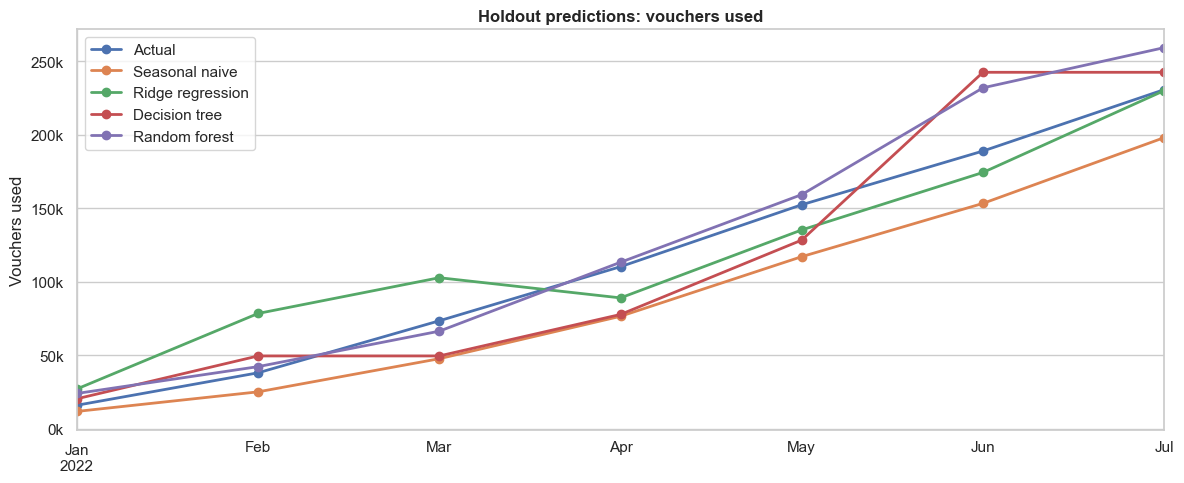

In [13]:
prediction_frame = pd.DataFrame({"Actual": y_test, **predictions})

display(prediction_frame.style.format("{:,.0f}"))

ax = prediction_frame.plot(marker="o", linewidth=2)
ax.set_title("Holdout predictions: vouchers used")
ax.set_xlabel("")
ax.set_ylabel("Vouchers used")
ax.yaxis.set_major_formatter(fmt_thousands)
plt.tight_layout()
plt.show()


Best holdout model by RMSE: Random forest


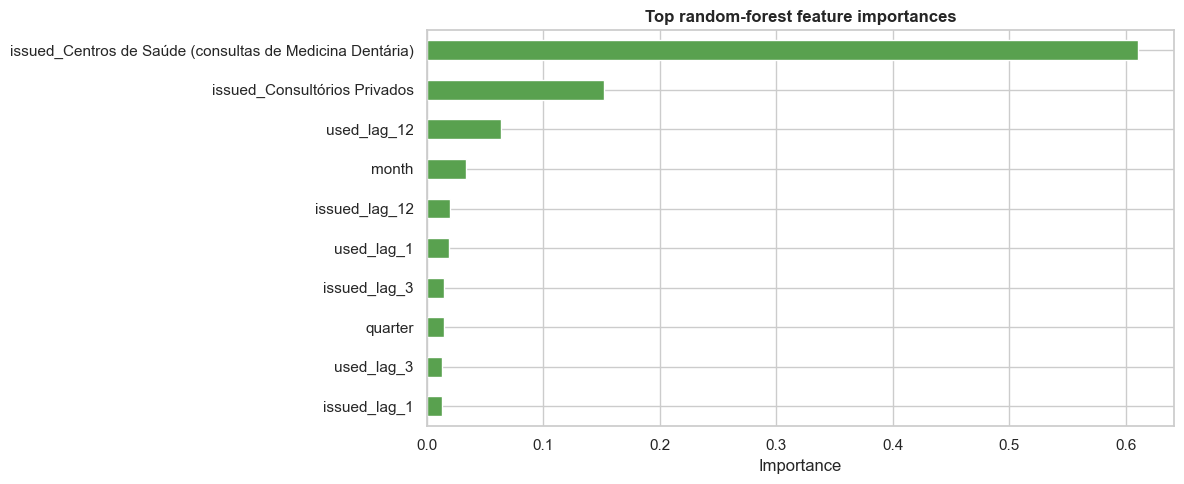

,importance
issued_Centros de Saúde (consultas de Medicina Dentária),0.611
issued_Consultórios Privados,0.152
used_lag_12,0.063
month,0.033
issued_lag_12,0.019
used_lag_1,0.019
issued_lag_3,0.015
quarter,0.015
used_lag_3,0.013
issued_lag_1,0.013


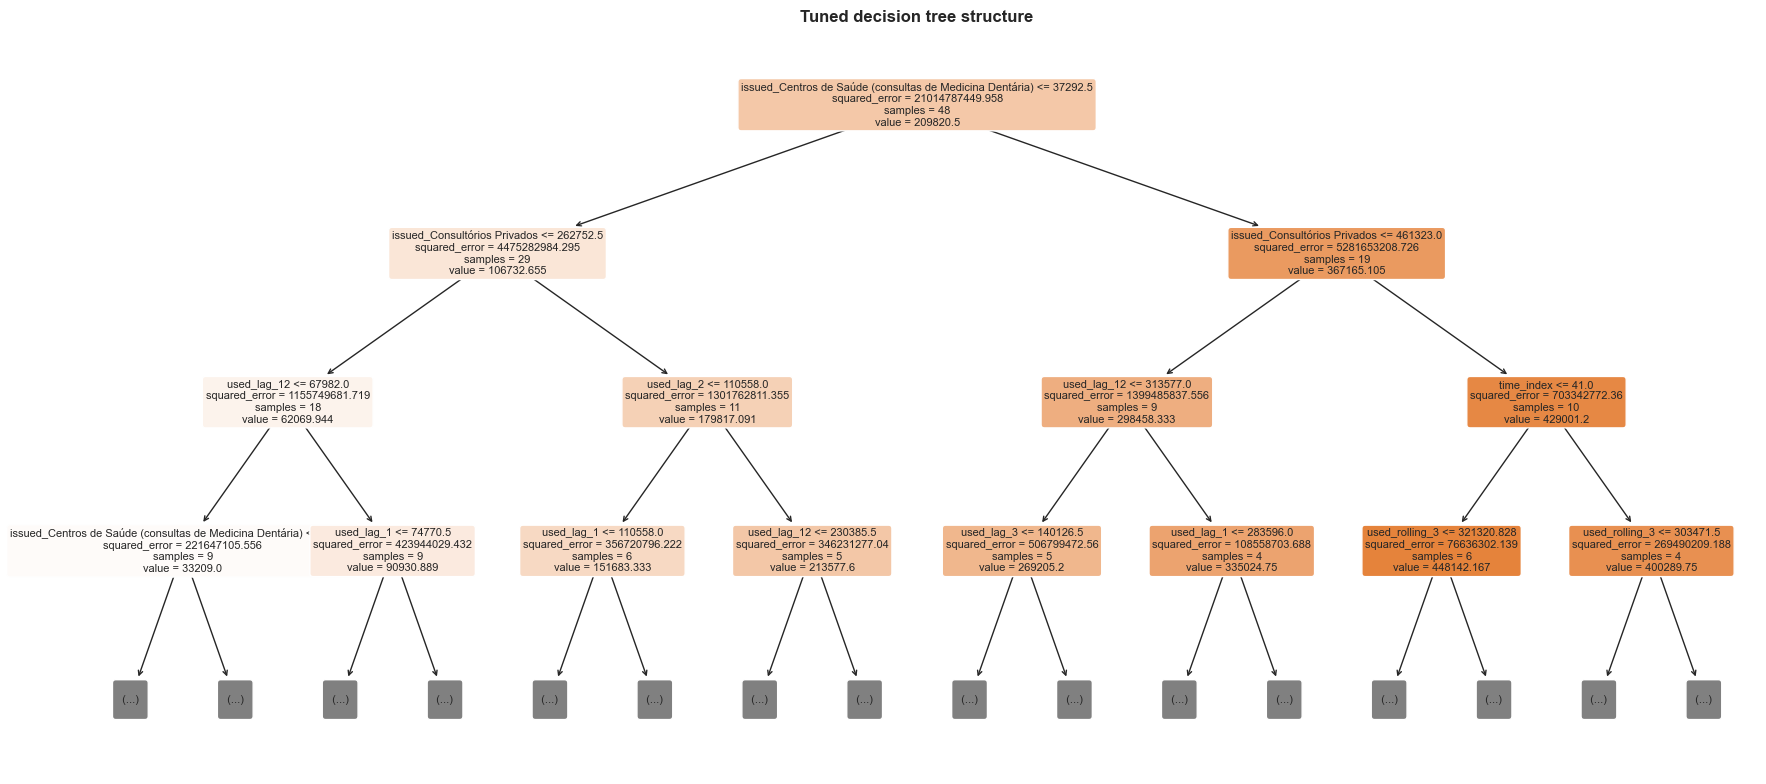

In [14]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best holdout model by RMSE: {best_model_name}")

if best_model_name == "Random forest":
    best_estimator = fitted_models[best_model_name].best_estimator_
    importances = pd.Series(best_estimator.feature_importances_, index=feature_columns).sort_values(ascending=False)
    ax = importances.head(10).sort_values().plot(kind="barh", color="#59A14F")
    ax.set_title("Top random-forest feature importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
    display(importances.head(10).to_frame("importance").style.format("{:.3f}"))
else:
    print("Feature-importance plot is shown only when Random forest is the best model.")

# Keep the interpretable tree visualization for the portfolio, using the tuned decision tree.
tree_model = fitted_models["Decision tree"].best_estimator_
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=feature_columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Tuned decision tree structure")
plt.tight_layout()
plt.show()


## Conclusion

The dataset is complete month-by-month from January 2017 to July 2022 and shows a highly seasonal public-service pattern. Most voucher usage is concentrated in private dental offices and among children and young people, while health-center activity is tied to more specific public-care pathways.

For modeling, the key correction is avoiding leakage from same-month used-voucher subgroup totals. With a leakage-aware feature set, the random forest performs best on the January-July 2022 holdout and improves on the seasonal naive benchmark. The benchmark remains important because the series is strongly seasonal; any model that cannot beat "same month last year" should not be used.

Further improvements would include adding external covariates such as school calendars, policy changes, appointment capacity, COVID restrictions, regional information, and voucher validity rules. With only monthly national aggregates, the model should be presented as a compact forecasting demonstration rather than a production-grade demand model.
